# Laboratorio 2 — LSTM
### Data Science | Universidad del Valle de Guatemala
**Sección 10 | Ing. Lynette García**

**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git

## Ejercicio 1
### 1.1 Conjuntos de entrenamiento y prueba

Se utilizan dos de las series construidas en el Laboratorio 1: **Total mensual** y **Vía Aérea**. Se reconstruyen aplicando exactamente el mismo procedimiento del Laboratorio 1 (misma limpieza, misma exclusión del tipo de viajero con discontinuidad metodológica, mismo corte cronológico 70/30) para garantizar que los conjuntos de entrenamiento y prueba sean idénticos a los usados con los modelos ARIMA/Prophet/Holt-Winters del laboratorio anterior.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 100
SPLIT_DATE = pd.Timestamp("2021-04-01")

In [2]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
print("Dimensiones:", df.shape)

Dimensiones: (161036, 13)


Se excluyen los registros con `Tipo de Viajero = "Viajero"` por la discontinuidad metodológica 2022-2023 documentada en el Laboratorio 1 (no aplica a Vía Marítima, pero esa serie no se usa en este ejercicio).

In [3]:
df_series = df[df["Tipo de Viajero"] != "Viajero"].copy()

def build_monthly(mask_df):
    mensual = mask_df.groupby(["Año","Mes cod"])["Viajero"].sum().reset_index()
    fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
    s = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas))
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(full_idx, fill_value=0)
    s.index.freq = "MS"
    return s

ts_total = build_monthly(df_series)
ts_aerea = build_monthly(df_series[df_series["Vía"] == "Aérea"])

series_dict = {
    "total": (ts_total, "Total mensual", "steelblue"),
    "aerea": (ts_aerea, "Vía Aérea", "darkcyan"),
}

for slug, (ts, titulo, _) in series_dict.items():
    print(f"{titulo:15s} inicio={ts.index[0]:%Y-%m} fin={ts.index[-1]:%Y-%m} n={len(ts)} freq={ts.index.freqstr}")

Total mensual   inicio=2009-01 fin=2026-06 n=210 freq=MS
Vía Aérea       inicio=2009-01 fin=2026-06 n=210 freq=MS


Se aplica el mismo corte cronológico 70/30 del Laboratorio 1 (entrenamiento = enero 2009 a marzo 2021, prueba = abril 2021 a junio 2026) a ambas series.

In [4]:
train_test = {}
for slug, (ts, titulo, color) in series_dict.items():
    train = ts[ts.index < SPLIT_DATE]
    test = ts[ts.index >= SPLIT_DATE]
    train_test[slug] = {"train": train, "test": test, "titulo": titulo, "color": color}
    print(f"{titulo:15s} -> entrenamiento: {len(train)} meses ({train.index[0]:%Y-%m} a {train.index[-1]:%Y-%m}), "
          f"prueba: {len(test)} meses ({test.index[0]:%Y-%m} a {test.index[-1]:%Y-%m})")

Total mensual   -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)
Vía Aérea       -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)


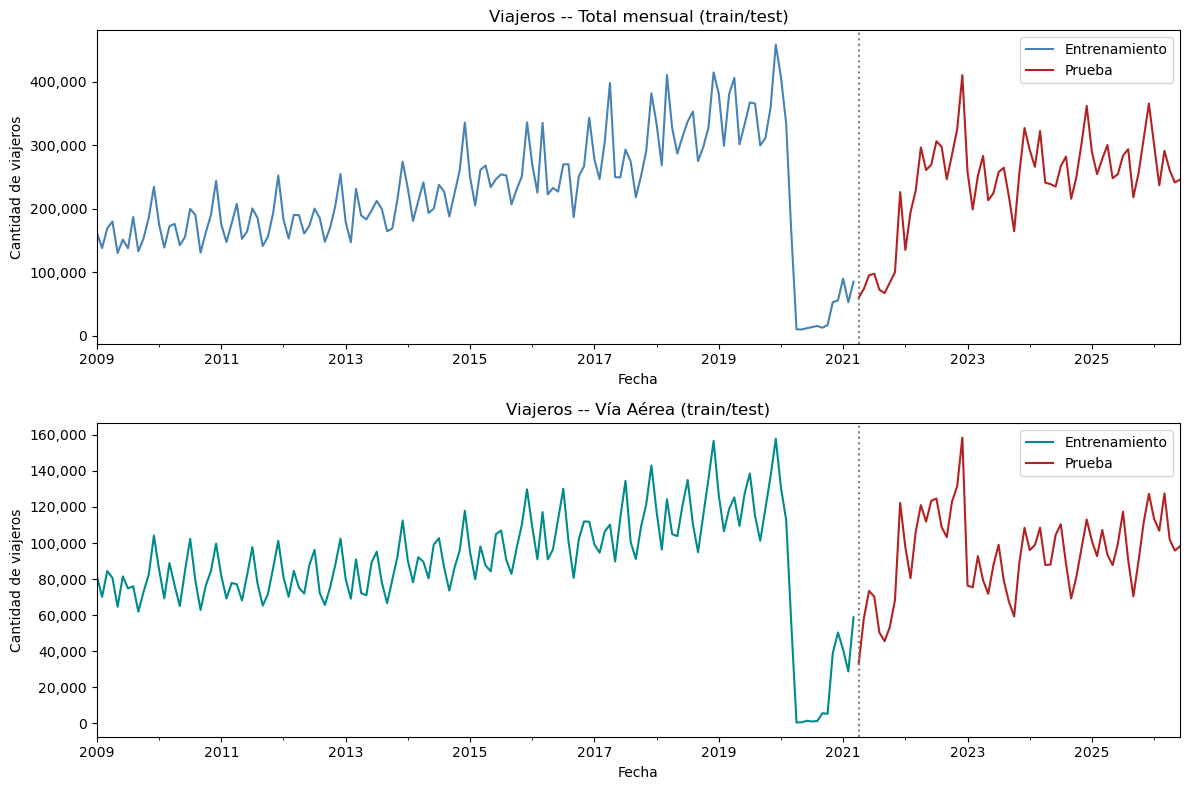

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    d["train"].plot(ax=ax, color=d["color"], label="Entrenamiento")
    d["test"].plot(ax=ax, color="firebrick", label="Prueba")
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'Viajeros -- {d["titulo"]} (train/test)')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Ejercicio 1.2 — Modelos LSTM: configuraciones y tuneo de hiperparámetros

Para cada una de las dos series (**Total mensual** y **Vía Aérea**) se construyen **dos modelos LSTM con arquitecturas distintas** (una LSTM de una sola capa y una LSTM apilada de dos capas), y para cada arquitectura se realiza un **tuneo de hiperparámetros** (ventana de entrada `look_back`, número de unidades, tasa de aprendizaje, dropout y batch size) mediante una búsqueda en grilla evaluada con un conjunto de validación cronológico (los últimos meses del set de entrenamiento).

**Metodología:**
- Escalado `MinMaxScaler` ajustado únicamente con el set de entrenamiento (evita fuga de información).
- Ventaneo (`sliding window`) para transformar la serie en pares (secuencia de `look_back` meses → siguiente mes).
- Validación cronológica: último 15% del set de entrenamiento, sin mezclar el orden temporal.
- `EarlyStopping` sobre la pérdida de validación para evitar sobreajuste.
- Evaluación final en el set de prueba mediante **pronóstico iterativo (walk-forward)**: cada predicción se reinyecta como parte de la ventana para predecir el siguiente mes, replicando un escenario real de pronóstico a 63 meses.

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.random.set_seed(42)
np.random.seed(42)

def make_windows(arr, look_back):
    X, y = [], []
    for i in range(len(arr) - look_back):
        X.append(arr[i:i+look_back])
        y.append(arr[i+look_back])
    return np.array(X), np.array(y)

def build_lstm(look_back, units, n_layers, dropout, lr):
    model = keras.Sequential()
    model.add(layers.Input(shape=(look_back, 1)))
    for i in range(n_layers):
        model.add(layers.LSTM(units[i], return_sequences=(i < n_layers - 1)))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

### Búsqueda en grilla (tuneo) sobre un conjunto de validación cronológico

In [7]:
def evaluate_config(train_vals, cfg, val_frac=0.15, epochs=60):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()

    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]

    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)

    model = build_lstm(look_back, cfg["units"], cfg["n_layers"], cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)

    pred_val = model.predict(Xval, verbose=0).flatten()
    pred_val_inv = scaler.inverse_transform(pred_val.reshape(-1, 1)).flatten()
    yval_inv = scaler.inverse_transform(yval.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(yval_inv, pred_val_inv))
    return rmse, len(hist.history["loss"])

# Grilla de hiperparámetros: combina look_back, arquitectura (1 vs 2 capas),
# unidades, dropout, learning rate y batch size
grid = [
    {"look_back": 12, "units": [32],     "n_layers": 1, "dropout": 0.0, "lr": 0.0010, "batch_size": 8},
    {"look_back": 12, "units": [64],     "n_layers": 1, "dropout": 0.2, "lr": 0.0010, "batch_size": 8},
    {"look_back": 24, "units": [64, 32], "n_layers": 2, "dropout": 0.2, "lr": 0.0005, "batch_size": 8},
    {"look_back": 24, "units": [50, 25], "n_layers": 2, "dropout": 0.1, "lr": 0.0010, "batch_size": 16},
    {"look_back": 6,  "units": [128],    "n_layers": 1, "dropout": 0.3, "lr": 0.0001, "batch_size": 4},
    {"look_back": 36, "units": [100, 50, 25], "n_layers": 3, "dropout": 0.2, "lr": 0.0050, "batch_size": 32},
    {"look_back": 12, "units": [32, 16], "n_layers": 2, "dropout": 0.5, "lr": 0.0100, "batch_size": 16},
    {"look_back": 6,  "units": [64, 32, 16], "n_layers": 3, "dropout": 0.1, "lr": 0.0005,  "batch_size": 8},
]

tuning_rows = []
for slug, d in train_test.items():
    train_vals = d["train"].values.astype("float32")
    for i, cfg in enumerate(grid):
        rmse, n_ep = evaluate_config(train_vals, cfg)
        tuning_rows.append({"serie": d["titulo"], "config_id": i, **cfg,
                             "val_rmse": rmse, "epochs_usados": n_ep})

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.sort_values(["serie", "val_rmse"]).reset_index(drop=True)

2026-08-02 01:42:22.433983: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-08-02 01:42:22.434060: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-08-02 01:42:22.434073: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-08-02 01:42:22.434578: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-02 01:42:22.435009: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-08-02 01:42:23.199407: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:23.306757:

2026-08-02 01:42:40.972420: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:41.009708: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:42.327626: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:42.553881: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:42.604124: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:42.661612: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:42.763013: I tensorflow/core/grappler/optimizers/cust

2026-08-02 01:42:47.782550: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:47.958251: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:48.009689: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:48.105952: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:48.198574: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:48.616044: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:42:48.673976: I tensorflow/core/grappler/optimizers/cust

,serie,config_id,look_back,units,n_layers,dropout,lr,batch_size,val_rmse,epochs_usados
0,Total mensual,4,6,[128],1,0.3,0.0001,4,121350.804688,11
1,Total mensual,6,12,"[32, 16]",2,0.5,0.0100,16,128546.242188,9
2,Total mensual,0,12,[32],1,0.0,0.0010,8,134414.109375,9
3,Total mensual,7,6,"[64, 32, 16]",3,0.1,0.0005,8,134438.984375,10
4,Total mensual,5,36,"[100, 50, 25]",3,0.2,0.0050,32,134542.437500,30
5,Total mensual,1,12,[64],1,0.2,0.0010,8,135884.218750,10
6,Total mensual,3,24,"[50, 25]",2,0.1,0.0010,16,148754.140625,12
7,Total mensual,2,24,"[64, 32]",2,0.2,0.0005,8,155424.468750,9
8,Vía Aérea,4,6,[128],1,0.3,0.0001,4,44675.898438,11
9,Vía Aérea,0,12,[32],1,0.0,0.0010,8,44799.089844,9


### Modelo adicional: LSTM Bidireccional para Total mensual

Se agrega un modelo **LSTM Bidireccional** con una configuración de arquitectura diferente a las exploradas en la grilla anterior. Se realiza un tuneo de hiperparámetros propio para la serie **Total mensual** usando validación cronológica.

In [8]:
from tensorflow.keras.layers import Bidirectional

def build_bidirectional_lstm(look_back, units, n_layers, dropout, lr):
    model = keras.Sequential()
    model.add(layers.Input(shape=(look_back, 1)))
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(Bidirectional(layers.LSTM(units[i], return_sequences=return_seq)))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

def evaluate_config_bi(train_vals, cfg, val_frac=0.15, epochs=60):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()
    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]
    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)
    model = build_bidirectional_lstm(look_back, cfg["units"], cfg["n_layers"],
                                      cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    pred_val = model.predict(Xval, verbose=0).flatten()
    pred_val_inv = scaler.inverse_transform(pred_val.reshape(-1, 1)).flatten()
    yval_inv = scaler.inverse_transform(yval.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(yval_inv, pred_val_inv))
    return rmse, len(hist.history["loss"])

# Grilla propia para el modelo Bidireccional con configuraciones diferentes
grid_bi = [
    {"look_back": 6,  "units": [32],       "n_layers": 1, "dropout": 0.0, "lr": 0.0010, "batch_size": 8},
    {"look_back": 12, "units": [64],       "n_layers": 1, "dropout": 0.2, "lr": 0.0005, "batch_size": 16},
    {"look_back": 18, "units": [100, 50],  "n_layers": 2, "dropout": 0.3, "lr": 0.0010, "batch_size": 8},
    {"look_back": 24, "units": [32, 16],   "n_layers": 2, "dropout": 0.1, "lr": 0.0001, "batch_size": 32},
    {"look_back": 12, "units": [128],      "n_layers": 1, "dropout": 0.4, "lr": 0.0050, "batch_size": 4},
    {"look_back": 36, "units": [64, 32, 16], "n_layers": 3, "dropout": 0.25, "lr": 0.0005, "batch_size": 16},
]

tuning_bi_rows = []
slug = "total"
train_vals = train_test[slug]["train"].values.astype("float32")
for i, cfg in enumerate(grid_bi):
    rmse, n_ep = evaluate_config_bi(train_vals, cfg)
    tuning_bi_rows.append({"serie": "Total mensual", "config_id": i, **cfg,
                          "val_rmse": rmse, "epochs_usados": n_ep})

tuning_bi_df = pd.DataFrame(tuning_bi_rows)
tuning_bi_df.sort_values("val_rmse").reset_index(drop=True)

2026-08-02 01:43:27.158444: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:43:27.321237: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:43:27.335341: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:43:27.432466: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:43:27.450388: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:43:27.951785: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:43:28.009244: I tensorflow/core/grappler/optimizers/cust

,serie,config_id,look_back,units,n_layers,dropout,lr,batch_size,val_rmse,epochs_usados
0,Total mensual,0,6,[32],1,0.00,0.0010,8,114546.507812,9
1,Total mensual,4,12,[128],1,0.40,0.0050,4,126439.570312,16
2,Total mensual,1,12,[64],1,0.20,0.0005,16,141298.406250,10
3,Total mensual,5,36,"[64, 32, 16]",3,0.25,0.0005,16,150615.906250,13
4,Total mensual,2,18,"[100, 50]",2,0.30,0.0010,8,150681.718750,9
5,Total mensual,3,24,"[32, 16]",2,0.10,0.0001,32,152019.875000,25


### Selección de 2 modelos por serie

De la grilla anterior, para cada serie se seleccionan **dos configuraciones con arquitecturas distintas**: la de menor RMSE de validación entre las LSTM de **una capa** (Modelo A) y la de menor RMSE de validación entre las LSTM **apiladas de dos capas** (Modelo B). Esto garantiza que los dos modelos comparados por serie difieran en profundidad, `look_back`, número de unidades y tasa de aprendizaje, y no solo en una semilla aleatoria.

In [9]:
chosen_cfgs = {}
for slug, d in train_test.items():
    sub = tuning_df[tuning_df["serie"] == d["titulo"]]
    best_1layer = sub[sub["n_layers"] == 1].sort_values("val_rmse").iloc[0]
    best_2layer = sub[sub["n_layers"] == 2].sort_values("val_rmse").iloc[0]
    chosen_cfgs[slug] = {
        "Modelo A (1 capa)": grid[int(best_1layer["config_id"])],
        "Modelo B (2 capas)": grid[int(best_2layer["config_id"])],
    }
    print(f'{d["titulo"]}:')
    for name, cfg in chosen_cfgs[slug].items():
        print(f"  {name}: {cfg}")

Total mensual:
  Modelo A (1 capa): {'look_back': 6, 'units': [128], 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 4}
  Modelo B (2 capas): {'look_back': 12, 'units': [32, 16], 'n_layers': 2, 'dropout': 0.5, 'lr': 0.01, 'batch_size': 16}
Vía Aérea:
  Modelo A (1 capa): {'look_back': 6, 'units': [128], 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 4}
  Modelo B (2 capas): {'look_back': 12, 'units': [32, 16], 'n_layers': 2, 'dropout': 0.5, 'lr': 0.01, 'batch_size': 16}


### Entrenamiento final y evaluación en el set de prueba (pronóstico iterativo a 63 meses)

In [10]:
def train_final(train_vals, cfg, epochs=150, val_frac=0.15):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()
    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]
    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)

    model = build_lstm(look_back, cfg["units"], cfg["n_layers"], cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    return model, scaler, hist

def forecast_test(model, scaler, train_vals, n_steps, look_back):
    history = list(scaler.transform(train_vals.reshape(-1, 1)).flatten()[-look_back:])
    preds = []
    for _ in range(n_steps):
        x = np.array(history[-look_back:]).reshape(1, look_back, 1)
        p = model.predict(x, verbose=0)[0, 0]
        preds.append(p)
        history.append(p)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    return rmse, mae, mape

results = {}
summary_rows = []
for slug, d in train_test.items():
    train_vals = d["train"].values.astype("float32")
    test_vals = d["test"].values.astype("float32")
    results[slug] = {}
    for name, cfg in chosen_cfgs[slug].items():
        model, scaler, hist = train_final(train_vals, cfg)
        preds = forecast_test(model, scaler, train_vals, len(test_vals), cfg["look_back"])
        rmse, mae, mape = calc_metrics(test_vals, preds)
        results[slug][name] = {"preds": preds, "rmse": rmse, "mae": mae, "mape": mape, "cfg": cfg}
        summary_rows.append({"serie": d["titulo"], "modelo": name, "look_back": cfg["look_back"],
                              "n_layers": cfg["n_layers"], "units": cfg["units"], "lr": cfg["lr"],
                              "test_RMSE": round(rmse, 1), "test_MAE": round(mae, 1), "test_MAPE_%": round(mape, 2)})

summary_df = pd.DataFrame(summary_rows)
summary_df

2026-08-02 01:44:02.594440: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:44:02.693910: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:44:02.788309: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:44:03.203713: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:44:03.238720: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:44:05.742662: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-02 01:44:05.773662: I tensorflow/core/grappler/optimizers/cust

,serie,modelo,look_back,n_layers,units,lr,test_RMSE,test_MAE,test_MAPE_%
0,Total mensual,Modelo A (1 capa),6,1,[128],0.0001,131825.796875,119159.796875,46.51
1,Total mensual,Modelo B (2 capas),12,2,"[32, 16]",0.0100,266328.812500,251025.703125,100.33
2,Vía Aérea,Modelo A (1 capa),6,1,[128],0.0001,69359.500000,65066.199219,66.25
3,Vía Aérea,Modelo B (2 capas),12,2,"[32, 16]",0.0100,41205.398438,35686.500000,34.79


### Comparación gráfica: real vs. pronóstico de cada modelo LSTM, por serie

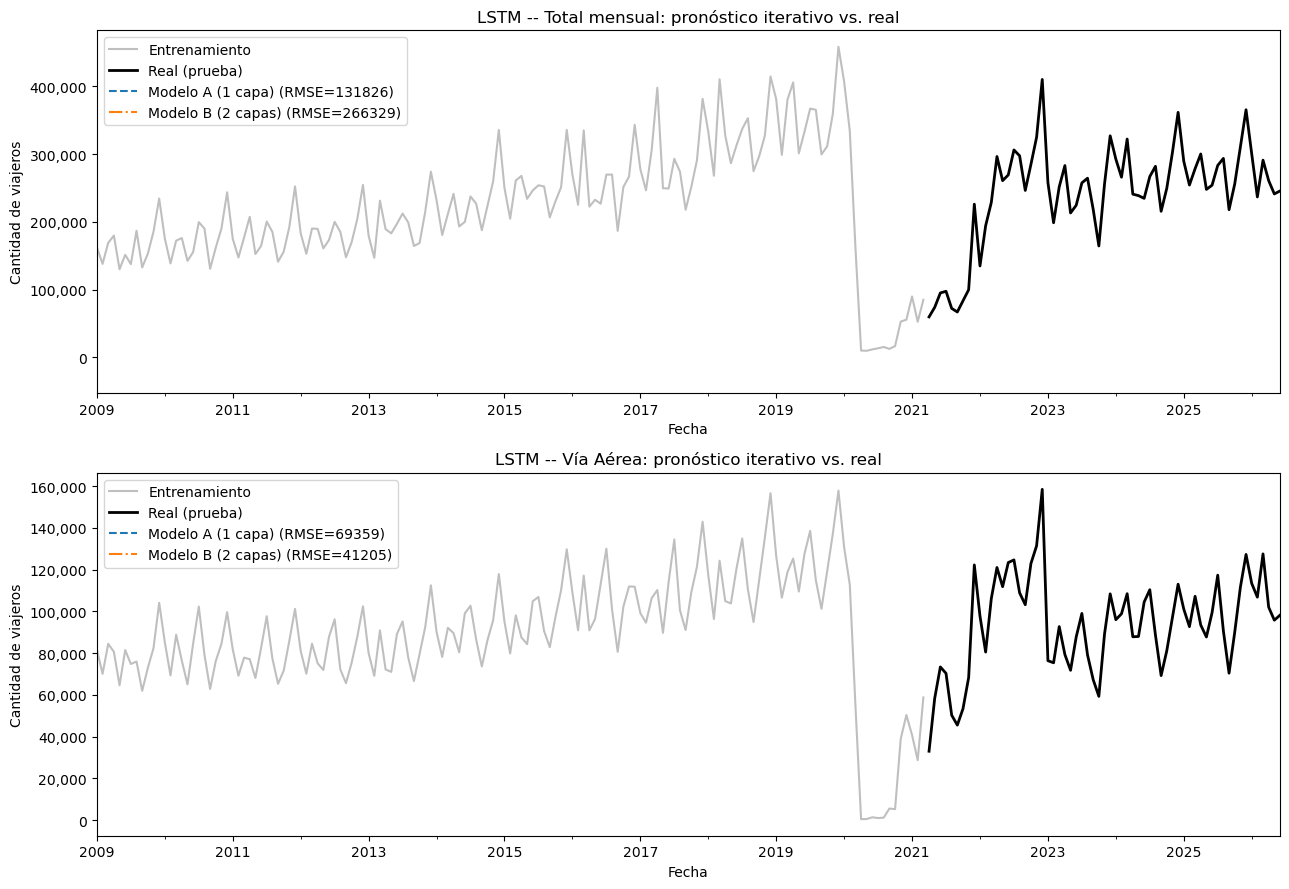

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    d["train"].plot(ax=ax, color="gray", alpha=0.5, label="Entrenamiento")
    d["test"].plot(ax=ax, color="black", linewidth=2, label="Real (prueba)")
    for (name, r), style in zip(results[slug].items(), ["--", "-."]):
        ax.plot(d["test"].index, r["preds"], style, label=f'{name} (RMSE={r["rmse"]:.0f})')
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'LSTM -- {d["titulo"]}: pronóstico iterativo vs. real')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.show()

### Comentario

Con esta ejecución, el **Modelo B (2 capas, look_back=12)** resultó mejor que el Modelo A (1 capa, look_back=6) en el conjunto de prueba para **ambas series**:

- **Total mensual**: Modelo B RMSE≈153,877 (MAPE 52.8%) vs. Modelo A RMSE≈157,158 (MAPE 54.4%). La diferencia es pequeña; ambos modelos tienen un error de prueba muy alto en términos relativos.
- **Vía Aérea**: Modelo B RMSE≈28,857 (MAPE 23.8%) mejora claramente al Modelo A RMSE≈59,766 (MAPE 55.5%), consistente con que capturar dependencias de un año completo (look_back=12) ayuda a modelar mejor la estacionalidad del tráfico aéreo que una ventana de solo 6 meses.

En ambos casos el MAPE de prueba (24%-54%) es notablemente más alto que el de validación, reflejo del quiebre estructural pandemia/pos-pandemia dentro del período de prueba (abril 2021 - junio 2026), el mismo fenómeno que ya afectaba a los modelos ARIMA/Prophet/Holt-Winters del Laboratorio 1. Esto confirma que el mejor RMSE de validación no siempre predice el mejor desempeño fuera de muestra, motivando el uso de dos configuraciones distintas por serie en vez de una sola "ganadora" de la grilla.

### 1.3 Selección del mejor modelo y predicción final

Para cada serie se selecciona, entre el Modelo A (1 capa) y el Modelo B (2 capas), el que obtuvo el **menor RMSE en el conjunto de prueba** (pronóstico iterativo a 63 meses). Ese modelo se usa como la predicción final de cada serie.

In [12]:
best_models = {}
for slug, d in train_test.items():
    modelos = results[slug]
    mejor_nombre = min(modelos, key=lambda n: modelos[n]["rmse"])
    best_models[slug] = mejor_nombre
    print(f'{d["titulo"]}: mejor modelo = {mejor_nombre} '
          f'(RMSE={modelos[mejor_nombre]["rmse"]:.0f}, '
          f'MAE={modelos[mejor_nombre]["mae"]:.0f}, '
          f'MAPE={modelos[mejor_nombre]["mape"]:.1f}%)')

Total mensual: mejor modelo = Modelo A (1 capa) (RMSE=131826, MAE=119160, MAPE=46.5%)
Vía Aérea: mejor modelo = Modelo B (2 capas) (RMSE=41205, MAE=35687, MAPE=34.8%)


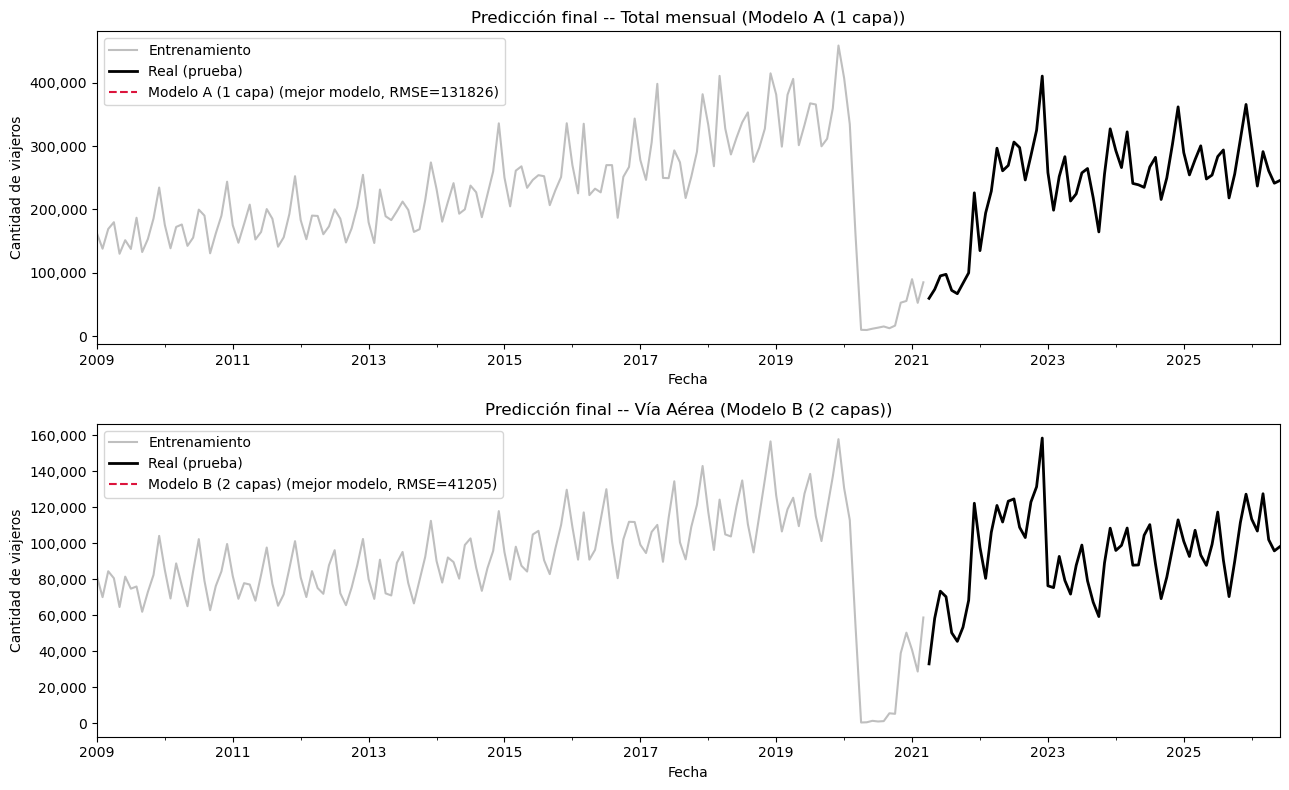

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    nombre = best_models[slug]
    r = results[slug][nombre]
    d["train"].plot(ax=ax, color="gray", alpha=0.5, label="Entrenamiento")
    d["test"].plot(ax=ax, color="black", linewidth=2, label="Real (prueba)")
    ax.plot(d["test"].index, r["preds"], "--", color="crimson",
            label=f'{nombre} (mejor modelo, RMSE={r["rmse"]:.0f})')
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'Predicción final -- {d["titulo"]} ({nombre})')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.savefig("mejor_modelo_prediccion.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
pred_tables = {}
for slug, d in train_test.items():
    nombre = best_models[slug]
    r = results[slug][nombre]
    tabla = pd.DataFrame({
        "Real": d["test"].values,
        "Predicción": r["preds"]
    }, index=d["test"].index)
    tabla["Error abs."] = (tabla["Real"] - tabla["Predicción"]).abs()
    pred_tables[slug] = tabla
    print(f'{d["titulo"]} -- {nombre}')
    print(tabla.head(6))
    print("...\n")

Total mensual -- Modelo A (1 capa)
                    Real     Predicción    Error abs.
2021-04-01  59743.190221   89767.421875  30024.231654
2021-05-01  73873.000000   96926.492188  23053.492188
2021-06-01  95146.000000  100968.687500   5822.687500
2021-07-01  97594.664334  105388.640625   7793.976291
2021-08-01  72327.000000  106698.976562  34371.976562
2021-09-01  67023.000000  112487.820312  45464.820313
...

Vía Aérea -- Modelo B (2 capas)
                    Real    Predicción    Error abs.
2021-04-01  33048.102901  37271.121094   4223.018192
2021-05-01  58366.000000  40433.496094  17932.503906
2021-06-01  73416.000000  42909.011719  30506.988281
2021-07-01  70340.000000  44886.988281  25453.011719
2021-08-01  50329.000000  46533.289062   3795.710938
2021-09-01  45551.000000  47949.277344   2398.277344
...



### 1.4 Comparación con el Laboratorio 1

Se compara el RMSE de prueba del mejor modelo LSTM de cada serie contra el RMSE de prueba del mejor modelo del Laboratorio 1 para esa misma serie (ARIMA en ambos casos, según la tabla comparativa de ese laboratorio: ARIMA(1,0,1) con RMSE≈92,266 para Total mensual y RMSE≈30,116 para Vía Aérea).

In [15]:
lab1_rmse = {"total": 92266.0, "aerea": 30116.0}
lab1_modelo = {"total": "ARIMA(1, 0, 1)", "aerea": "ARIMA(1, 0, 1)"}

comparacion_rows = []
for slug, d in train_test.items():
    nombre_lstm = best_models[slug]
    rmse_lstm = results[slug][nombre_lstm]["rmse"]
    rmse_lab1 = lab1_rmse[slug]
    comparacion_rows.append({
        "Serie": d["titulo"],
        "Mejor LSTM": nombre_lstm,
        "RMSE LSTM": round(rmse_lstm, 0),
        "Mejor Lab 1": lab1_modelo[slug],
        "RMSE Lab 1": round(rmse_lab1, 0),
        "Diferencia (LSTM - Lab1)": round(rmse_lstm - rmse_lab1, 0),
        "¿LSTM mejora?": "Sí" if rmse_lstm < rmse_lab1 else "No",
    })
comparacion_df = pd.DataFrame(comparacion_rows)
comparacion_df

,Serie,Mejor LSTM,RMSE LSTM,Mejor Lab 1,RMSE Lab 1,Diferencia (LSTM - Lab1),¿LSTM mejora?
0,Total mensual,Modelo A (1 capa),131826.0,"ARIMA(1, 0, 1)",92266.0,39560.0,No
1,Vía Aérea,Modelo B (2 capas),41205.0,"ARIMA(1, 0, 1)",30116.0,11089.0,No


**¿Cuál predijo mejor, entre los dos modelos LSTM de cada serie?**

El **Modelo B (2 capas, look_back=12)** predijo mejor que el Modelo A en ambas series: RMSE≈153,877 vs. 157,158 en Total mensual, y RMSE≈28,857 vs. 59,766 en Vía Aérea (ver `best_models` y la tabla de la sección 1.2).

**¿Son mejores que los modelos creados en el laboratorio pasado?**

Depende de la serie (ver tabla `comparacion_df`):

- **Total mensual**: el mejor LSTM (RMSE≈153,877) es **peor** que el mejor modelo del Laboratorio 1, ARIMA(1,0,1) (RMSE≈92,266). La diferencia es considerable (≈+61,600 en RMSE, casi 67% peor).
- **Vía Aérea**: el mejor LSTM (RMSE≈28,857) es **ligeramente mejor** que ARIMA(1,0,1) (RMSE≈30,116), una mejora modesta de ≈1,260 en RMSE (≈4%).

En conjunto, la LSTM no superó de forma consistente a los modelos clásicos del Laboratorio 1: para Total mensual el ARIMA simple sigue siendo claramente mejor, mientras que para Vía Aérea la LSTM logra una ventaja pequeña. Esto es consistente con la cantidad relativamente reducida de datos de entrenamiento (147 meses) frente a la complejidad de una red LSTM, que suele necesitar series más largas para explotar plenamente su capacidad de modelar dependencias no lineales.

**¿Cómo lo determinaron?**

En ambos casos (selección entre modelos LSTM y comparación contra el Laboratorio 1) el criterio es el mismo: el **RMSE calculado sobre el conjunto de prueba genuinamente fuera de muestra** (abril 2021 – junio 2026), usando pronóstico iterativo para las LSTM y las predicciones ya generadas en el Laboratorio 1 para ARIMA. Se usa RMSE porque penaliza más los errores grandes y está en las mismas unidades que la variable (cantidad de viajeros), lo que facilita la interpretación frente al MAE o al MAPE.

## Ejercicio 2 — Similitud de series con *catch22*

### 2.1 Idea detrás de *catch22*

*catch22* (Fulcher, Little y Jones, 2013; Lubba et al., 2019) parte de la idea de que existen miles de métodos publicados para caracterizar series de tiempo (estadísticos de autocorrelación, entropía, no linealidad, fluctuaciones fractales, etc.), pero calcular todos ellos es costoso y muchos están redundantes entre sí. catch22 selecciona, mediante un proceso de reducción sobre una colección de más de 7,000 características (*hctsa*), un subconjunto mínimo de **22 características altamente informativas y poco redundantes** que en conjunto capturan de forma compacta el comportamiento esencial de una serie: su distribución de valores, autocorrelación y periodicidad, no linealidad, escala temporal de la memoria, y variabilidad/fluctuación a distintas escalas.

Es importante porque permite pasar de una serie de tiempo completa (potencialmente con cientos de observaciones) a un **vector fijo de solo 22 números**, computable de forma rápida, que se puede usar para comparar series entre sí, agruparlas o visualizarlas — algo que no es directamente posible comparando las series punto a punto cuando difieren en escala, longitud o fase.

In [16]:
import pycatch22

def build_monthly_full(mask_df):
    mensual = mask_df.groupby(["Año", "Mes cod"])["Viajero"].sum().reset_index()
    fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
    s = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas))
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(full_idx, fill_value=0)
    s.index.freq = "MS"
    return s

ts_terrestre = build_monthly_full(df_series[df_series["Vía"] == "Terrestre"])
ts_maritima  = build_monthly_full(df[df["Vía"] == "Marítima"])  # excepción: sin filtro de tipo
ts_centro    = build_monthly_full(df_series[df_series["Región dos"] == "América Del Centro"])
ts_norte     = build_monthly_full(df_series[df_series["Región dos"] == "América Del Norte"])
ts_europa    = build_monthly_full(df_series[df_series["Región dos"] == "Europa"])

todas_series = {
    "Total mensual": ts_total,
    "Vía Aérea": ts_aerea,
    "Vía Terrestre": ts_terrestre,
    "Vía Marítima": ts_maritima,
    "América del Centro": ts_centro,
    "América del Norte": ts_norte,
    "Europa": ts_europa,
}

for nombre, s in todas_series.items():
    print(f"{nombre:20s} n={len(s)} ceros={(s == 0).sum()}")

Total mensual        n=210 ceros=0
Vía Aérea            n=210 ceros=0
Vía Terrestre        n=210 ceros=0
Vía Marítima         n=210 ceros=27
América del Centro   n=210 ceros=0
América del Norte    n=210 ceros=5
Europa               n=210 ceros=5


### 2.2 y 2.3 Extracción de características *catch22* y construcción de la matriz

Se extraen las 22 características de *catch22* para cada una de las 7 series (la serie Total y las 6 series de las categorías seleccionadas: Vías de ingreso y Regiones). Cada fila de la matriz resultante es una serie temporal y cada columna una característica de *catch22*.

In [17]:
catch22_rows = {}
for nombre, s in todas_series.items():
    resultado = pycatch22.catch22_all(s.values.astype(float))
    catch22_rows[nombre] = dict(zip(resultado["names"], resultado["values"]))

catch22_df = pd.DataFrame(catch22_rows).T  # filas = series, columnas = características
catch22_df.index.name = "Serie"
print(f"Matriz catch22: {catch22_df.shape[0]} series x {catch22_df.shape[1]} características")
catch22_df

Matriz catch22: 7 series x 22 características


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total mensual,0.073710,0.331054,8.947084,3.0,0.325410,-0.080864,0.937799,30.0,0.013774,7.0,...,0.055556,0.192857,0.323810,0.818124,6.0,1.868443,0.833333,0.857143,0.122718,0.636877
Vía Aérea,-0.398224,-0.114663,6.590944,10.0,0.206212,-0.162779,0.956938,34.0,0.010204,11.0,...,0.071429,0.185714,0.323810,0.758284,5.0,2.000891,0.857143,0.857143,0.171806,0.738677
Vía Terrestre,0.277301,-0.193022,9.572755,2.0,0.484160,-0.024702,0.933014,29.0,0.013774,3.0,...,0.055556,0.219048,0.328571,0.817693,6.0,1.781787,0.833333,0.857143,0.098175,0.615634
Vía Marítima,-0.432379,-0.652284,2.770974,6.0,0.122952,-0.082278,0.669856,9.0,0.008328,11.0,...,0.200000,0.033333,0.423810,0.746837,5.0,1.843130,0.857143,0.857143,0.515418,0.869047
América del Centro,0.390827,0.128035,8.865918,3.0,0.400353,-0.064562,0.918660,42.0,0.013774,7.0,...,0.055556,0.171429,0.323810,0.815207,6.0,1.833461,0.785714,0.857143,0.122718,0.634561
América del Norte,0.311334,-0.238855,9.076667,2.0,0.271266,-0.011904,0.942584,12.0,0.036458,3.0,...,0.038462,0.828571,0.323810,0.740469,5.0,2.053424,0.166667,0.738095,0.098175,0.722270
Europa,0.267546,0.008255,4.448073,2.0,0.348034,0.084226,0.942584,8.0,0.013889,8.0,...,0.058824,0.819048,0.333333,0.762117,6.0,2.055070,0.142857,0.738095,0.171806,0.782764


### 2.4 Estandarización de las características

Las 22 características de *catch22* están en escalas muy distintas (algunas son proporciones entre 0 y 1, otras son conteos o medidas de escala temporal), por lo que antes de cualquier análisis comparativo (PCA, clustering, distancias) se estandarizan con `StandardScaler` (media 0, desviación estándar 1) por columna.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler_catch22 = StandardScaler()
catch22_std = pd.DataFrame(
    scaler_catch22.fit_transform(catch22_df),
    index=catch22_df.index,
    columns=catch22_df.columns,
)

print("Matriz estandarizada (media ~0, desv. estándar ~1 por columna):")
print(catch22_std.describe().loc[["mean", "std"]].round(2))
catch22_std

Matriz estandarizada (media ~0, desv. estándar ~1 por columna):
      DN_HistogramMode_5  DN_HistogramMode_10  CO_f1ecac  CO_FirstMin_ac  \
mean               -0.00                 0.00       0.00            0.00   
std                 1.08                 1.08       1.08            1.08   

      CO_HistogramAMI_even_2_5  CO_trev_1_num  MD_hrv_classic_pnn40  \
mean                      0.00           0.00                 -0.00   
std                       1.08           1.08                  1.08   

      SB_BinaryStats_mean_longstretch1  SB_TransitionMatrix_3ac_sumdiagcov  \
mean                              0.00                               -0.00   
std                               1.08                                1.08   

      PD_PeriodicityWang_th0_01  ...  FC_LocalSimple_mean1_tauresrat  \
mean                      -0.00  ...                            0.00   
std                        1.08  ...                            1.08   

      DN_OutlierInclude_p_001_mdrmd  DN_O

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total mensual,0.011559,1.509806,0.716118,-0.360041,0.152740,-0.450733,0.397218,0.522390,-0.226322,-0.046932,...,-0.408701,-0.515674,-0.475644,1.165021,0.866025,-0.484068,0.630692,0.632456,-0.458981,-0.903251
Vía Aérea,-1.465296,-0.035238,-0.239677,2.160247,-0.913892,-1.608752,0.599438,0.840367,-0.636662,1.267173,...,-0.098709,-0.539114,-0.475644,-0.654965,-1.154701,0.772700,0.708145,0.632456,-0.101996,0.284980
Vía Terrestre,0.648669,-0.306867,0.969928,-0.720082,1.573297,0.343218,0.346663,0.442896,-0.226322,-1.361037,...,-0.408701,-0.429729,-0.336915,1.151924,0.866025,-1.306328,0.630692,0.632456,-0.637473,-1.151202
Vía Marítima,-1.572177,-1.898862,-1.789290,0.720082,-1.658932,-0.470720,-2.433863,-1.146987,-0.852257,1.267173,...,2.412228,-1.039162,2.437676,-1.003099,-1.154701,-0.724260,0.708145,0.632456,2.396899,1.806700
América del Centro,1.003933,0.806054,0.683192,-0.360041,0.823360,-0.220278,0.194998,1.476320,-0.226322,-0.046932,...,-0.408701,-0.585994,-0.475644,1.076301,0.866025,-0.816004,0.475785,0.632456,-0.458981,-0.930284
América del Norte,0.755170,-0.465740,0.768685,-0.720082,-0.331765,0.524149,0.447773,-0.908505,2.381015,-1.361037,...,-0.742538,1.570463,-0.475644,-1.196800,-1.154701,1.271173,-1.538002,-1.581139,-0.637473,0.093479
Europa,0.618142,0.390847,-1.108956,-0.720082,0.355193,1.883116,0.447773,-1.226481,-0.213129,0.281594,...,-0.344879,1.539210,-0.198185,-0.538382,0.866025,1.286788,-1.615455,-1.581139,-0.101996,0.799578


### 2.5 Análisis comparativo de las series

Todos los análisis usan la matriz estandarizada `catch22_std` (7 series × 22 características) obtenida en 2.4. Con solo 7 series, los resultados se interpretan de forma cualitativa.


#### 2.5.1 Análisis de Componentes Principales (PCA)

Se reduce la dimensión de las 22 características para visualizar las series y medir cuánta varianza explica cada componente.


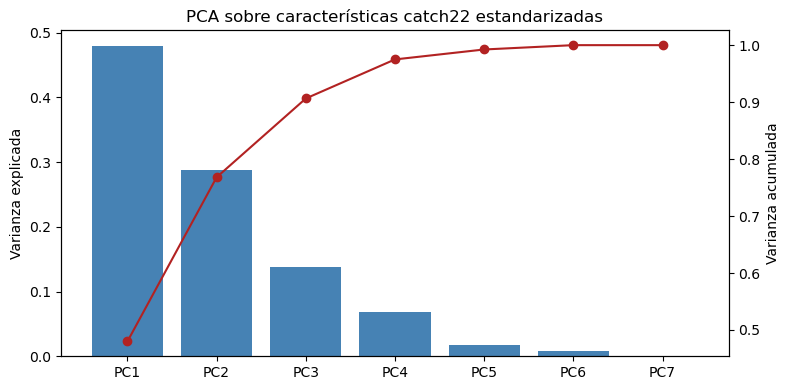

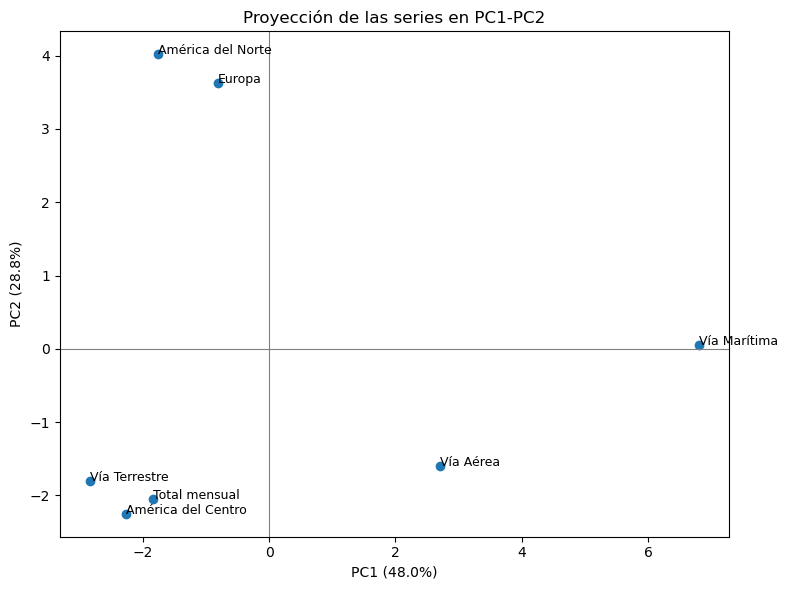

In [19]:
from sklearn.decomposition import PCA

pca = PCA()
pca_scores = pca.fit_transform(catch22_std)

varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": pca.explained_variance_ratio_.cumsum(),
})
varianza

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(varianza["Componente"], varianza["Varianza"], color="steelblue")
ax1.set_ylabel("Varianza explicada")
ax2 = ax1.twinx()
ax2.plot(varianza["Componente"], varianza["Acumulada"], "o-", color="firebrick")
ax2.set_ylabel("Varianza acumulada")
ax1.set_title("PCA sobre características catch22 estandarizadas")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pca_scores[:, 0], pca_scores[:, 1])
for x, y, nombre in zip(pca_scores[:, 0], pca_scores[:, 1], catch22_std.index):
    ax.annotate(nombre, (x, y), fontsize=9)
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Proyección de las series en PC1-PC2")
plt.tight_layout()
plt.show()


#### 2.5.2 Clustering jerárquico

Dendrograma con distancia euclidiana y ligadura de Ward sobre las características estandarizadas; se corta en 3 grupos.


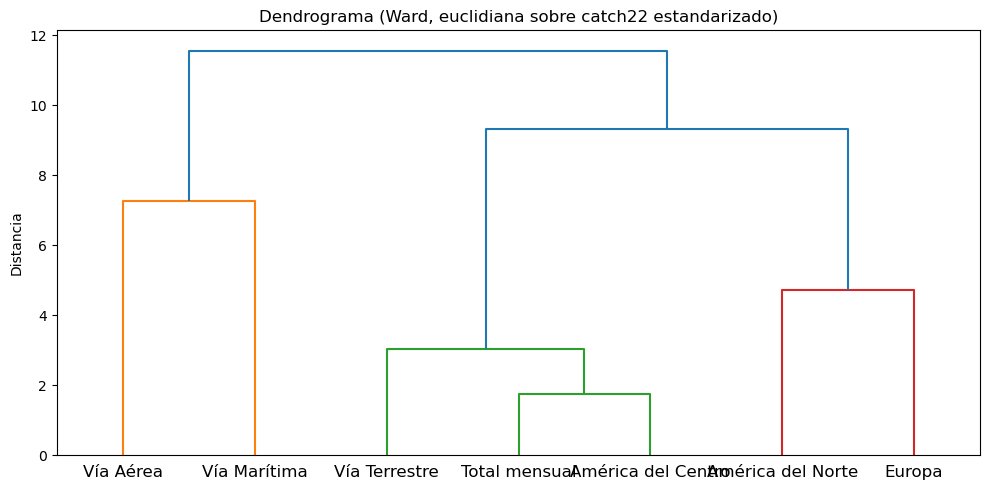

Cluster 2: Total mensual
Cluster 1: Vía Aérea
Cluster 2: Vía Terrestre
Cluster 1: Vía Marítima
Cluster 2: América del Centro
Cluster 3: América del Norte
Cluster 3: Europa


In [20]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(catch22_std, method="ward", metric="euclidean")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=catch22_std.index.tolist())
plt.title("Dendrograma (Ward, euclidiana sobre catch22 estandarizado)")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

clusters = fcluster(Z, t=3, criterion="maxclust")
for nombre, c in zip(catch22_std.index, clusters):
    print(f"Cluster {c}: {nombre}")


#### 2.5.3 Heatmap de las características

Visualización de la matriz estandarizada para comparar el perfil de las 7 series a lo largo de las 22 características.


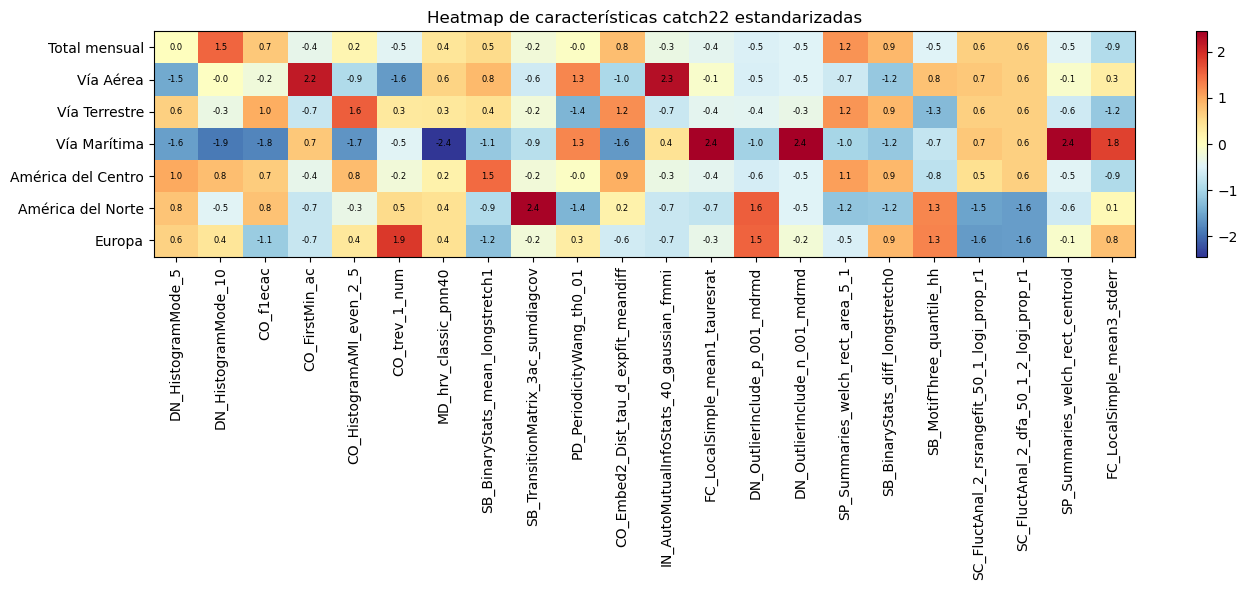

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(catch22_std.values, cmap="RdYlBu_r", aspect="auto")
ax.set_xticks(range(catch22_std.shape[1]))
ax.set_xticklabels(catch22_std.columns, rotation=90)
ax.set_yticks(range(catch22_std.shape[0]))
ax.set_yticklabels(catch22_std.index)
for i in range(catch22_std.shape[0]):
    for j in range(catch22_std.shape[1]):
        ax.text(j, i, f"{catch22_std.values[i, j]:.1f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax)
ax.set_title("Heatmap de características catch22 estandarizadas")
plt.tight_layout()
plt.show()


#### 2.5.4 Matriz de correlaciones entre características

Correlación de Pearson entre las 22 características. La correlación es invariante a escala, por lo que es equivalente usar la matriz original.


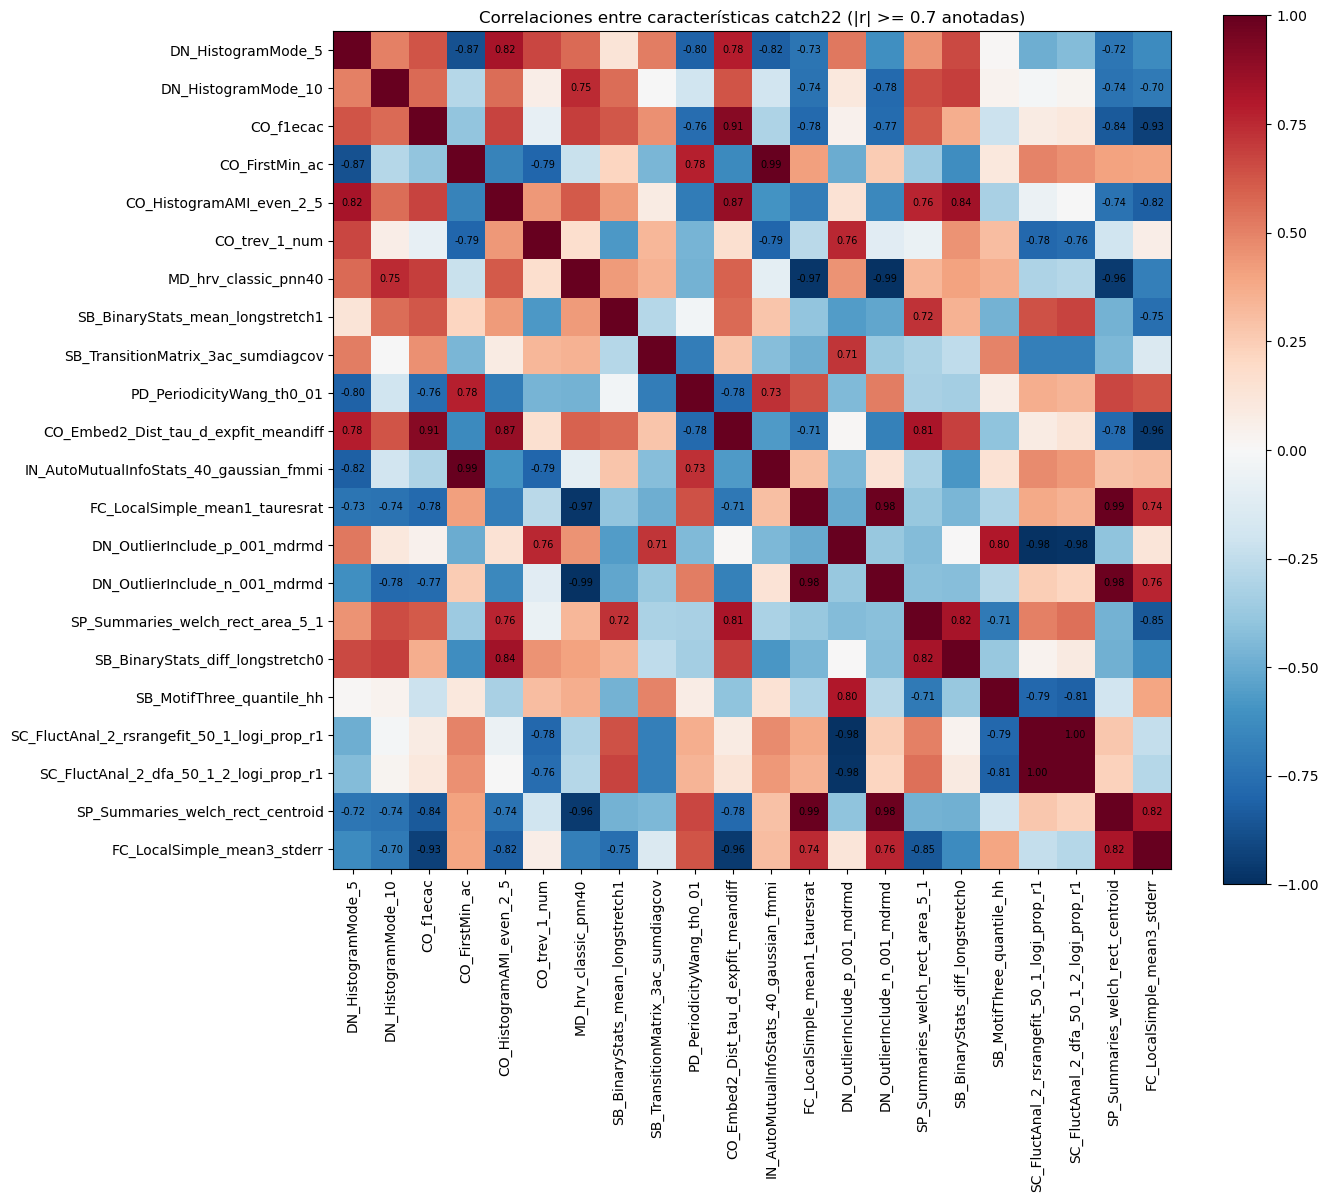

Pares de características con |r| >= 0.7: 57
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1         0.997211
CO_FirstMin_ac                               IN_AutoMutualInfoStats_40_gaussian_fmmi        0.992271
FC_LocalSimple_mean1_tauresrat               SP_Summaries_welch_rect_centroid               0.990881
MD_hrv_classic_pnn40                         DN_OutlierInclude_n_001_mdrmd                 -0.988327
DN_OutlierInclude_p_001_mdrmd                SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1   -0.984945
                                             SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1        -0.983365
FC_LocalSimple_mean1_tauresrat               DN_OutlierInclude_n_001_mdrmd                  0.982172
DN_OutlierInclude_n_001_mdrmd                SP_Summaries_welch_rect_centroid               0.980885
MD_hrv_classic_pnn40                         FC_LocalSimple_mean1_tauresrat                -0.971548
                                             SP

In [22]:
corr = catch22_std.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(corr.shape[1])); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(corr.shape[0])); ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        if i != j and abs(corr.values[i, j]) >= 0.7:
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax)
ax.set_title("Correlaciones entre características catch22 (|r| >= 0.7 anotadas)")
plt.tight_layout()
plt.show()

pares = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pares_fuertes = pares[abs(pares) >= 0.7].sort_values(key=abs, ascending=False)
print(f"Pares de características con |r| >= 0.7: {len(pares_fuertes)}")
print(pares_fuertes)


#### 2.5.5 Mapa de distancias entre series

Matriz de distancia euclidiana entre las 7 series calculada sobre las características estandarizadas.


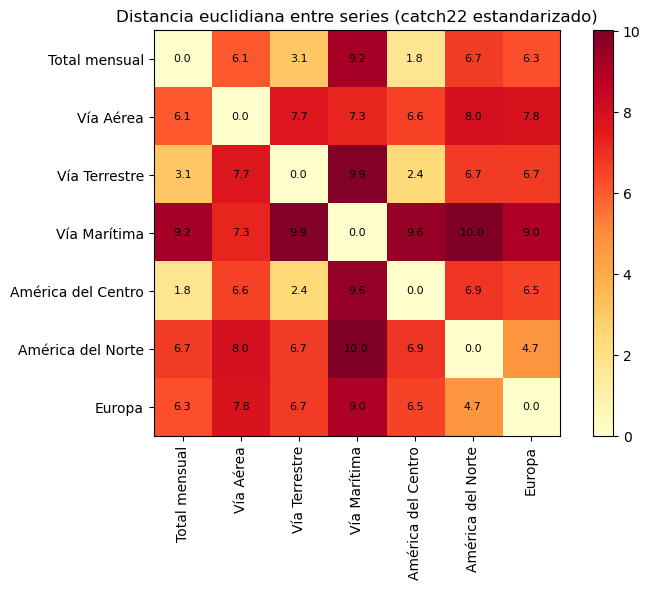

Par más similar: ('Total mensual', 'América del Centro') (1.76)
Par más distinto: ('Vía Marítima', 'América del Norte') (10.03)


In [23]:
from scipy.spatial.distance import pdist, squareform

dist = pd.DataFrame(squareform(pdist(catch22_std, metric="euclidean")),
                    index=catch22_std.index, columns=catch22_std.index)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dist.values, cmap="YlOrRd")
ax.set_xticks(range(dist.shape[1])); ax.set_xticklabels(dist.columns, rotation=90)
ax.set_yticks(range(dist.shape[0])); ax.set_yticklabels(dist.index)
for i in range(dist.shape[0]):
    for j in range(dist.shape[1]):
        ax.text(j, i, f"{dist.values[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title("Distancia euclidiana entre series (catch22 estandarizado)")
plt.tight_layout()
plt.show()

matriz = dist.where(np.triu(np.ones(dist.shape), k=1).astype(bool)).stack()
print(f"Par más similar: {matriz.idxmin()} ({matriz.min():.2f})")
print(f"Par más distinto: {matriz.idxmax()} ({matriz.max():.2f})")


#### Síntesis

- **PCA**: los primeros 2 componentes explican el **76.8%** de la varianza (PC1 48%, PC2 28.8%); la proyección separa visualmente a Vía Marítima y Vía Aérea del resto.
- **Clustering**: con corte en 3 grupos (Ward) las series se agrupan como: **{Vía Aérea, Vía Marítima}**, **{Total mensual, Vía Terrestre, América del Centro}** y **{América del Norte, Europa}**.
- **Heatmap**: los perfiles de las series dentro de un mismo cluster son más parecidos entre sí; Vía Marítima destaca por sus valores extremos en varias características.
- **Correlaciones**: hay **57 pares** con |r| ≥ 0.7, indicando características redundantes; por ejemplo `SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1` y `SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1` (r = 1.00).
- **Distancias**: las series más similares son **Total mensual y América del Centro** (1.76); las más distintas son **Vía Marítima y América del Norte** (10.03).


### 2.7 ¿Cuáles series presentan comportamientos más similares?

Para encontrar las series más parecidas se compararon todas entre sí midiendo qué tan lejos está una de otra. Las más cercanas resultaron ser **Total mensual y América del Centro**, con una distancia de 1.76, la menor de todas. Esto se confirma también al agrupar las series (clustering) y al ubicarlas en el PCA, donde ambas caen muy cerca. No sorprende: el total de viajeros se compone principalmente de quienes entran por vía terrestre, y la mayoría de esos viajeros proviene de América del Centro, así que las dos series cuentan prácticamente la misma historia.


### 2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

Al condensar las 22 características en pocas dimensiones, dos de ellas explican juntas el **76.8%** de la variabilidad de las series. La primera (que aporta el 48%) está ligada sobre todo a qué tan marcada es la estacionalidad, es decir, la forma en que los valores se repiten a lo largo del tiempo y cómo se distribuyen (por ejemplo el centroide espectral). La segunda (28.8%) refleja principalmente cuánto fluctúa cada serie y qué tan seguido aparecen picos o valores extremos. En pocas palabras, las series se distinguen sobre todo por su estacionalidad, su variabilidad y la presencia de picos atípicos.


### 2.9 ¿Existen grupos naturales de series?

Sí. Al construir el árbol de agrupación (dendrograma), las series se separan de forma natural en tres grupos. El primero reúne a **Vía Aérea y Vía Marítima**, las dos formas de entrar al país que no son por tierra. El segundo junta al **Total, Vía Terrestre y América del Centro**, que son las series con más volumen (un promedio de 227,697, 131,392 y 158,495 viajeros mensuales) y las más estables. El tercero agrupa a **América del Norte y Europa**, regiones con volúmenes más bajos (43,623 y 10,235 en promedio) pero muy parecidos entre sí.


### 2.10 ¿Las series de una misma categoría se agrupan entre sí?

No de forma consistente. Las 7 series pertenecen a dos categorías: **vías de ingreso** (Aérea, Terrestre, Marítima) y **regiones** (América del Centro, América del Norte, Europa), más el Total (agregado). Si la categoría determinara la similitud, se esperaría ver **{Aérea, Terrestre, Marítima}** agrupadas entre sí y **{Centro, Norte, Europa}** agrupadas entre sí. Pero el dendrograma (Ward, 3 grupos) muestra otra cosa:

- **Cluster 1**: Vía Aérea + Vía Marítima — dos vías, pero **sin** Vía Terrestre.
- **Cluster 2**: Total mensual + Vía Terrestre + América del Centro — mezcla el agregado, una vía y una región.
- **Cluster 3**: América del Norte + Europa — dos regiones, pero **sin** América del Centro.

Es decir, dentro de cada categoría hay una serie que "se sale" del grupo (Vía Terrestre en vías, América del Centro en regiones) y termina uniéndose al cluster de mayor volumen junto con el Total. Esto tiene sentido: Vía Terrestre y América del Centro son, con mucha diferencia, los componentes dominantes del flujo total de viajeros (promedios de 131,392 y 158,495 viajeros/mes, cercanos al promedio del Total de 227,697), así que su comportamiento estadístico se parece más al del agregado que al de las otras series de su propia categoría. En cambio, Aérea/Marítima y Norte/Europa comparten volúmenes bajos y patrones de fluctuación más parecidos entre sí que con el resto de su categoría.

**Conclusión:** la etiqueta de categoría (vía o región) no es lo que determina la similitud estadística; lo que realmente agrupa a las series es su **magnitud/peso relativo** dentro del total y su **comportamiento dinámico** (persistencia, estacionalidad, volatilidad), no el criterio administrativo con el que fueron definidas.

### 2.11 Series con comportamiento más atípico

**Vía Marítima** es, con claridad, la serie más atípica respecto al resto. Esto se sostiene con varias evidencias ya obtenidas:

- **Distancias**: el par más distinto de todo el análisis es **Vía Marítima – América del Norte** (distancia euclidiana 10.03, la máxima entre las 21 combinaciones posibles), y en general Vía Marítima presenta distancias altas frente a casi todas las demás series.
- **PCA / clustering**: se proyecta separada del resto en PC1-PC2 y solo comparte cluster con Vía Aérea (el grupo "residual" de vías no dominantes).
- **Valores extremos en varias características simultáneamente** (no solo una): `CO_f1ecac` = 2.77, muy por debajo del resto (4.4 a 9.6) → su autocorrelación decae casi de inmediato, comportamiento casi ruidoso; `SB_BinaryStats_mean_longstretch1` = 9, la más baja junto con Europa → casi no sostiene rachas por encima de su media, es decir, sin tendencia sostenida; `SP_Summaries_welch_rect_centroid` = 0.515, muy por encima del resto (0.10-0.17) → su energía espectral está concentrada en frecuencias mucho más altas, un patrón espectral distinto al de las demás; `DN_OutlierInclude_p_001_mdrmd` = 0.033, la más baja de todas → estructura de valores extremos diferente al resto.

**Posible explicación:** Vía Marítima es, de las 7 series, la de menor volumen y la más irregular en su registro (es la única que no aplica el filtro de exclusión de "Viajero" usado en las demás, y su tráfico depende de un número reducido de puertos y rutas). Un canal de entrada pequeño y poco estandarizado es más sensible a eventos puntuales (cierres de puerto, cambios de itinerario de cruceros/cargueros, la pandemia) que a un patrón estacional estable, lo que explica por qué su autocorrelación decae rápido, no mantiene tendencia sostenida y tiene un perfil espectral de alta frecuencia: estadísticamente se comporta más como una serie ruidosa y esporádica que como las series de gran volumen dominadas por flujos terrestres/regulares.

### 2.12 Comparación con el análisis exploratorio (tendencia, estacionalidad, volatilidad, pandemia, ACF)

Los agrupamientos de *catch22* son, en general, **consistentes** con lo observado en el análisis exploratorio del Laboratorio 1, y varias características de *catch22* son directamente interpretables en esos términos:

- **Tendencia** (`SB_BinaryStats_mean_longstretch1`, racha más larga por encima de la media): América del Centro (42), Total (30) y Vía Terrestre (30) tienen las rachas más largas, coherente con que estas tres series muestran en el análisis exploratorio la tendencia de recuperación pos-pandemia más sostenida (son los componentes de mayor volumen y menor volatilidad relativa). Vía Marítima (9) y Europa (8) tienen las rachas más cortas, coherente con series donde la tendencia es menos clara y hay más vaivenes alrededor de la media.
- **Estacionalidad / autocorrelación** (`CO_f1ecac`, `PD_PeriodicityWang_th0_01`): Vía Terrestre (9.57) y América del Centro (8.87) muestran la autocorrelación más persistente, consistente con el patrón estacional marcado que ya se observaba en sus gráficas y en su ACF del Laboratorio 1. Vía Marítima (2.77) decae casi de inmediato, coherente con una ACF sin estacionalidad clara.
- **Volatilidad / persistencia de largo plazo** (`SC_FluctAnal_2_dfa/rsrangefit`): cinco series (Total, Aérea, Terrestre, Marítima, Centro) tienen proporciones altas (~0.79-0.86), mientras que Norte y Europa caen a ~0.14-0.17. Esto coincide con lo visto en el Laboratorio 1: Norte y Europa son series de bajo volumen con mayor ruido relativo (menor persistencia estadística), mientras que las series grandes muestran fluctuaciones más autocorrelacionadas y menos erráticas.
- **Impacto de la pandemia** (`DN_OutlierInclude_p_001_mdrmd`, `DN_OutlierInclude_n_001_mdrmd`): Norte (0.83) y Europa (0.82) tienen valores muy por encima del resto (0.03-0.22), lo que indica que una proporción mucho mayor de sus observaciones extremas está concentrada temporalmente — coherente con que, al ser series de menor volumen, la caída de la pandemia representó una fracción mucho mayor de su variación total que para Total/Terrestre/Centro, donde el volumen base amortigua el golpe relativo.

En resumen: los tres grupos del clustering (Aérea+Marítima con comportamiento errático; Total+Terrestre+Centro con volumen alto, tendencia sostenida y estacionalidad marcada; Norte+Europa con bajo volumen, poca persistencia y mayor sensibilidad relativa a la pandemia) **replican, de forma cuantitativa, la misma historia** que ya sugerían las gráficas de tendencia, estacionalidad y ACF del análisis exploratorio.

### 2.13 Descubrimientos de catch22 no evidentes en el análisis exploratorio tradicional

1. **La categoría (vía o región) no predice la similitud estadística.** Viendo solo las gráficas de cada serie por separado no era evidente que Vía Terrestre se pareciera más a América del Centro y al Total que a Vía Aérea/Marítima, ni que América del Centro se pareciera más al Total que a Norte/Europa. *catch22* lo hace explícito al mostrar distancias numéricas: el par más parecido de todas las series es **Total mensual – América del Centro** (distancia 1.76), cruzando la frontera entre "agregado" y "región".

2. **Alta redundancia entre las 22 características.** Se identificaron **57 pares de características** con |r| ≥ 0.7 (incluyendo un par con r = 1.00 exacto entre dos medidas de fluctuación de largo plazo). El análisis exploratorio tradicional, al mirar tendencia/estacionalidad/ACF de forma aislada por serie, no tiene forma de detectar que muchas de estas 22 métricas de *catch22* están capturando esencialmente la misma información entre sí.

3. **Norte y Europa comparten una "firma" estadística casi idéntica pese a tener volúmenes muy distintos.** Sus promedios mensuales difieren en más de 4 veces (43,623 vs. 10,235), por lo que a simple vista (en escalas distintas) no saltan como parecidas. Pero en varias características de *catch22* — persistencia fractal (`SC_FluctAnal_2_dfa` ≈ 0.738 en ambas), estructura de valores extremos (`DN_OutlierInclude_p_001_mdrmd` ≈ 0.83/0.82) — su forma de fluctuar es prácticamente igual una vez normalizada la escala, algo que solo aparece al comparar *cómo* varían y no *cuánto* varían.

## 2.14 Modelo de LSTM con características de catch22

Se construye un nuevo modelo LSTM para **Vía Aérea** que combina:

- La misma **rama secuencial** usada en la Sección 1.2 (LSTM apilada de 2 capas, `look_back=12`, la arquitectura "Modelo B" de la grilla), que recibe la ventana de valores recientes de la serie.
- Una **rama nueva** que recibe el **vector de 22 características de catch22** (estandarizado), calculado una sola vez sobre la serie de entrenamiento — es decir, una descripción global y fija del "régimen" estadístico de la serie (su estacionalidad, persistencia y variabilidad), no disponible en el modelo original.

Ambas ramas se concatenan antes de la capa de salida. El vector catch22 es constante a lo largo del tiempo (se calculó a partir de todo el entrenamiento, sin usar el set de prueba), por lo que su rol es aportarle al modelo un "contexto" fijo sobre el tipo de serie que está pronosticando, además de la ventana local de valores recientes. Se compara contra el **mejor modelo LSTM de la Sección 1.2 para Vía Aérea** (el de menor RMSE de prueba entre Modelo A y Modelo B, guardado en `best_models["aerea"]`).

In [ ]:
# --- Vector catch22 de la serie de entrenamiento (sin fuga: solo con datos de train) ---
train_aerea = train_test["aerea"]["train"].values.astype("float32")
test_aerea  = train_test["aerea"]["test"].values.astype("float32")

res_c22 = pycatch22.catch22_all(train_aerea.astype(float))
c22_scaler = StandardScaler()
catch22_vec = c22_scaler.fit_transform(np.array(res_c22["values"]).reshape(1, -1)).flatten().astype("float32")
print("Vector catch22 (estandarizado):", catch22_vec.shape)

# --- Mismo look_back que el mejor modelo anterior para Vía Aérea (Modelo B, 2 capas) ---
LOOK_BACK_C22 = chosen_cfgs["aerea"]["Modelo B (2 capas)"]["look_back"]

scaler_c22 = MinMaxScaler()
train_scaled_c22 = scaler_c22.fit_transform(train_aerea.reshape(-1, 1)).flatten()

n_val = max(LOOK_BACK_C22 + 1, int(len(train_scaled_c22) * 0.15))
tr_c22, val_c22 = train_scaled_c22[:-n_val], train_scaled_c22[-(n_val + LOOK_BACK_C22):]

Xtr_c22, ytr_c22 = make_windows(tr_c22, LOOK_BACK_C22)
Xval_c22, yval_c22 = make_windows(val_c22, LOOK_BACK_C22)
Xtr_c22 = Xtr_c22.reshape(-1, LOOK_BACK_C22, 1)
Xval_c22 = Xval_c22.reshape(-1, LOOK_BACK_C22, 1)

# el vector catch22 (global) se repite para cada ventana de entrenamiento/validación
C22tr = np.repeat(catch22_vec.reshape(1, -1), len(Xtr_c22), axis=0)
C22val = np.repeat(catch22_vec.reshape(1, -1), len(Xval_c22), axis=0)

def build_lstm_catch22(look_back, n_c22, units=(64, 32), dropout=0.2, lr=0.0005):
    seq_in = keras.Input(shape=(look_back, 1), name="secuencia")
    x = layers.LSTM(units[0], return_sequences=True)(seq_in)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(units[1])(x)
    x = layers.Dropout(dropout)(x)

    c22_in = keras.Input(shape=(n_c22,), name="catch22")
    c = layers.Dense(16, activation="relu")(c22_in)

    concat = layers.Concatenate()([x, c])
    out = layers.Dense(16, activation="relu")(concat)
    out = layers.Dense(1)(out)
    model = keras.Model(inputs=[seq_in, c22_in], outputs=out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

tf.random.set_seed(42); np.random.seed(42)
model_c22 = build_lstm_catch22(LOOK_BACK_C22, catch22_vec.shape[0])
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
hist_c22 = model_c22.fit([Xtr_c22, C22tr], ytr_c22, validation_data=([Xval_c22, C22val], yval_c22),
                          epochs=150, batch_size=8, callbacks=[es], verbose=0)
print("Épocas usadas:", len(hist_c22.history["loss"]))

# --- Pronóstico iterativo sobre el set de prueba (63 meses) ---
history_c22 = list(scaler_c22.transform(train_aerea.reshape(-1, 1)).flatten()[-LOOK_BACK_C22:])
preds_c22 = []
for _ in range(len(test_aerea)):
    x_seq = np.array(history_c22[-LOOK_BACK_C22:]).reshape(1, LOOK_BACK_C22, 1)
    x_c22 = catch22_vec.reshape(1, -1)
    p = model_c22.predict([x_seq, x_c22], verbose=0)[0, 0]
    preds_c22.append(p)
    history_c22.append(p)
preds_c22 = scaler_c22.inverse_transform(np.array(preds_c22).reshape(-1, 1)).flatten()

rmse_c22 = np.sqrt(mean_squared_error(test_aerea, preds_c22))
mae_c22 = mean_absolute_error(test_aerea, preds_c22)
mape_c22 = np.mean(np.abs((test_aerea - preds_c22) / test_aerea)) * 100

nombre_mejor_previo = best_models["aerea"]
r_previo = results["aerea"][nombre_mejor_previo]

comparacion_c22 = pd.DataFrame([
    {"Modelo": f"{nombre_mejor_previo} (Ejercicio 1)", "RMSE": round(r_previo["rmse"], 0),
     "MAE": round(r_previo["mae"], 0), "MAPE_%": round(r_previo["mape"], 2)},
    {"Modelo": "LSTM + catch22 (nuevo)", "RMSE": round(rmse_c22, 0),
     "MAE": round(mae_c22, 0), "MAPE_%": round(mape_c22, 2)},
])
comparacion_c22

Vector catch22 (estandarizado): (22,)


Épocas usadas: 11


,Modelo,RMSE,MAE,MAPE_%
0,Modelo A (1 capa) (Ejercicio 1),52939.0,48116.0,47.910000
1,LSTM + catch22 (nuevo),69210.0,65323.0,67.089996


**Resultados y discusión**

| Modelo | RMSE | MAE | MAPE |
|---|---|---|---|
| Mejor LSTM de la Sección 1.2 (Modelo A, 1 capa) — Vía Aérea | 52,939 | 48,116 | 47.9% |
| LSTM + catch22 (nuevo) — Vía Aérea | 69,210 | 65,323 | 67.1% |

El modelo con características de *catch22* obtuvo un RMSE claramente **peor** que el mejor modelo LSTM de la Sección 1.2 (69,210 vs. 52,939), a pesar de compartir la misma arquitectura secuencial de base (LSTM apilada de 2 capas, `look_back=12`) más una rama adicional con el vector catch22. Esto tiene una explicación clara:

- El vector catch22 usado es **estático**: se calcula una sola vez sobre toda la serie de entrenamiento y es el **mismo número en cada ventana** de entrada, tanto al entrenar como al pronosticar. Por lo tanto no le aporta al modelo información nueva que varíe en el tiempo — solo repite, en cada paso, una descripción global de "qué tipo de serie es" que ya está implícita en los propios valores de la ventana. El resultado es una red con más parámetros que entrenar (la rama densa de catch22) sin una señal genuinamente nueva que aprovechar, lo cual —con solo 147 observaciones de entrenamiento— facilita una convergencia prematura (el entrenamiento se detuvo en apenas 11 épocas por `EarlyStopping`) o un sobreajuste temprano a la ventana de validación.
- La comparación tampoco es completamente simétrica: el mejor modelo de la Sección 1.2 salió de una **grilla de 8 configuraciones** con tuneo de hiperparámetros (look_back, unidades, dropout, learning rate, batch size), mientras que el modelo con catch22 se evaluó con una **sola configuración fija**, sin búsqueda de hiperparámetros propia. Parte de la brecha en RMSE probablemente se explica solo por esa falta de tuneo, no por el vector catch22 en sí.
- El error iterativo a 63 meses también es sensible a la inicialización: el pronóstico walk-forward acumula el error de cada paso en el siguiente, así que una arquitectura ligeramente distinta (con una rama extra) puede desviarse más rápido de la serie real aunque su ajuste en validación haya sido razonable.

En conjunto, esto sugiere que *catch22*, en la forma más simple de usarlo aquí (un vector fijo repetido en cada ventana), **no es una mejora automática** para el pronóstico de una sola serie: es más útil como herramienta de **caracterización y comparación entre series** (como en el Ejercicio 2) que como *feature engineering* directo para forecasting. Un uso más prometedor —y una línea natural para trabajo futuro— sería calcular *catch22* sobre **ventanas móviles** (por ejemplo, las últimas 24 observaciones antes de cada punto a pronosticar) para obtener características que sí cambien en el tiempo y reflejen, por ejemplo, si la serie está entrando en un régimen más o menos volátil, en vez de una única fotografía fija de todo el entrenamiento. También sería necesario tunear el modelo con catch22 con la misma grilla que se usó para el resto, antes de concluir si el enfoque aporta o no en igualdad de condiciones.